# 1. Постановка задачи 


Нужно спрогнозировать, какого типа звезда. Вам предоставлены исторические данные звезд и их типах

Примечание: такого звезд в реальности не существует. Данные о них вымышлены (синтезированы).ся.

# 2.Подключение данных

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

# 3. Загрузка данных 

In [2]:
star = pd.read_csv("Stars.csv")

In [3]:
star.head(10)

,Temperature,L,R,A_M,Color,Spectral_Class,Type
0,3068,0.002400,0.1700,16.12,Red,M,0
1,3042,0.000500,0.1542,16.60,Red,M,0
2,2600,0.000300,0.1020,18.70,Red,M,0
3,2800,0.000200,0.1600,16.65,Red,M,0
4,1939,0.000138,0.1030,20.06,Red,M,0
5,2840,0.000650,0.1100,16.98,Red,M,0
6,2637,0.000730,0.1270,17.22,Red,M,0
7,2600,0.000400,0.0960,17.40,Red,M,0
8,2650,0.000690,0.1100,17.45,Red,M,0
9,2700,0.000180,0.1300,16.05,Red,M,0


### Описание данных

Признаки:
- Temperature - Температура (в Кельвинах)
- L - Светимость (в единицах светимости Солнца)
- R - Радиус (в единицах радиуса Солнца)
- A_M - Абсолютная звездная величина
- Color - Цвет звезды
- Spectral_Class - Спектральный класс
- Type - Тип звезды

In [4]:
star.shape

(240, 7)

In [5]:
star.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature     240 non-null    int64  
 1   L               240 non-null    float64
 2   R               240 non-null    float64
 3   A_M             240 non-null    float64
 4   Color           240 non-null    object 
 5   Spectral_Class  240 non-null    object 
 6   Type            240 non-null    int64  
dtypes: float64(3), int64(2), object(2)
memory usage: 13.3+ KB


Пропущенных значений не было обнаружено

In [6]:
star.describe()

,Temperature,L,R,A_M,Type
count,240.000000,240.000000,240.000000,240.000000,240.000000
mean,10497.462500,107188.361635,237.157781,4.382396,2.500000
std,9552.425037,179432.244940,517.155763,10.532512,1.711394
min,1939.000000,0.000080,0.008400,-11.920000,0.000000
25%,3344.250000,0.000865,0.102750,-6.232500,1.000000
50%,5776.000000,0.070500,0.762500,8.313000,2.500000
75%,15055.500000,198050.000000,42.750000,13.697500,4.000000
max,40000.000000,849420.000000,1948.500000,20.060000,5.000000


Для того чтобы нормализовать эти данные, нужно учитывать, что температура зависит от класса звезды 
- звезды класса А от 7400 до 10000
- звезды класса В от 10000 до 30000
- звезды класса F от 6000 до 7500
- звезды класса G от 5000 до 6000
- звезды класса K от 3500 до 5000
- звезды класса M от 2000 до 3000
- звезды класса O от 30000 до 60000
  нужно заменить аномальные значения для каждого класса на медианные

Минимальный радиус звезды примерно 0.008 а максимальный 2000, так что данные соответствуют


Абсолютная величина звезды так же соответствует максимальным и минимальным параметрам от -11 до 20


Светимость звезды так же зависит от ее класса

Перед нормализацией выведем все данные до изменений, чтобы увидеть что мы не сильно изменили данные

<Axes: >

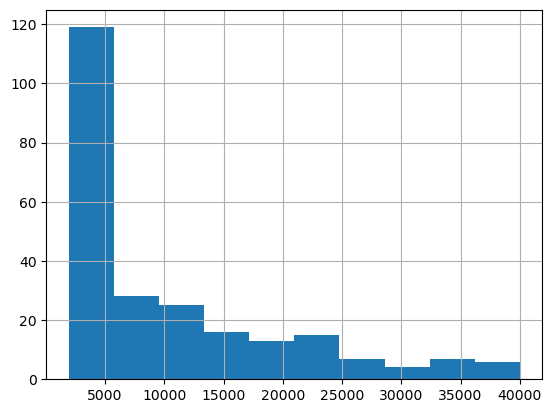

In [7]:
star["Temperature"].hist()

In [8]:

temp_ranges = {
    'O': (30000, 60000),
    'B': (10000, 30000), 
    'A': (7400, 10000),
    'F': (6000, 7500),
    'G': (5000, 6000),
    'K': (3500, 5000),
    'M': (2000, 3500)
}
for star_class, (min_temp, max_temp) in temp_ranges.items():
    mask = star['Spectral_Class'] == star_class
    class_stars = star[mask]
    
    if len(class_stars) > 0:
        median_temp = class_stars['Temperature'].median()
        anomaly_mask = mask & ((star['Temperature'] < min_temp) | (star['Temperature'] > max_temp))
        star.loc[anomaly_mask, 'Temperature'] = median_temp

C:\Users\User\AppData\Local\Temp\ipykernel_8636\1219052205.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '4406.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  star.loc[anomaly_mask, 'Temperature'] = median_temp


<Axes: >

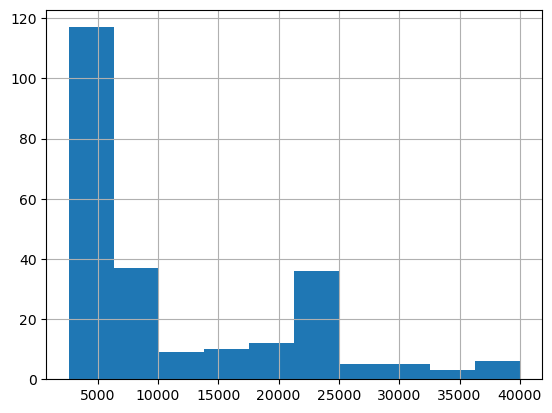

In [9]:
star["Temperature"].hist()

После проверки можно увидеть, что данные не сильно изменились.

<Axes: >

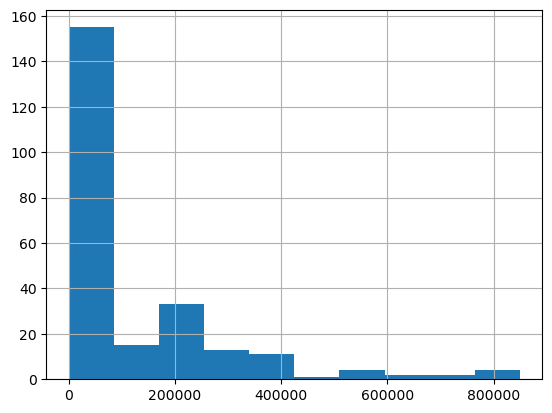

In [10]:
star["L"].hist()

In [11]:
luminosity_limits = {
    'O': (10000, 1000000),
    'B': (100, 10000),
    'A': (10, 100),
    'F': (2, 10),
    'G': (0.5, 2),
    'K': (0.1, 0.5),
    'M': (0.0001, 0.1)
}
for star_class, (min_lum, max_lum) in luminosity_limits.items():
    mask = star['Spectral_Class'] == star_class
    class_median = star[mask]['L'].median()
    anomaly_mask = mask & ((star['L'] < min_lum) | (star['L'] > max_lum))
    star.loc[anomaly_mask, 'L'] = class_median
    print(f"Класс {star_class}: исправлено {anomaly_mask.sum()} аномалий светимости")

Класс O: исправлено 0 аномалий светимости
Класс B: исправлено 41 аномалий светимости
Класс A: исправлено 16 аномалий светимости
Класс F: исправлено 15 аномалий светимости
Класс G: исправлено 1 аномалий светимости
Класс K: исправлено 4 аномалий светимости
Класс M: исправлено 31 аномалий светимости


<Axes: >

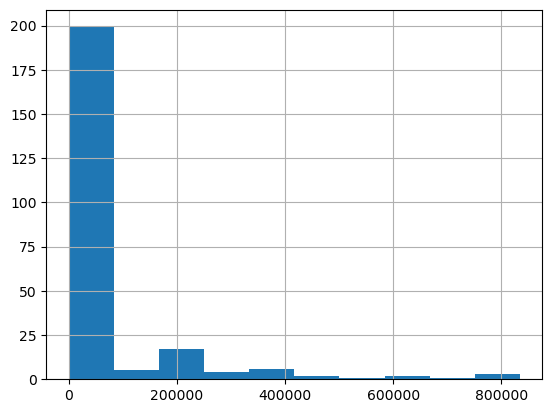

In [12]:
star["L"].hist()

In [13]:
star.describe(include=[object])

,Color,Spectral_Class
count,240,240
unique,17,7
top,Red,M
freq,112,111


In [14]:
star.dtypes

Temperature       float64
L                 float64
R                 float64
A_M               float64
Color              object
Spectral_Class     object
Type                int64
dtype: object

Приведем текстовые значения к одному регистру воизбежании ошибок:

In [15]:
star['Color'] = star['Color'].str.title() 
star['Spectral_Class'] = star['Spectral_Class'].str.title() 

# 4. Разведочный анализ данных(EDA)

### Проверка на пропущенные и дублирующие значения

In [16]:
star.isna().sum()

Temperature       0
L                 0
R                 0
A_M               0
Color             0
Spectral_Class    0
Type              0
dtype: int64

Наш набор данных не имеет пропущенных значений и нет необимости в том, чтобы заполнять пустые значения. Поэтому мы можем перейти к подробному анализу наших данных

### 1. Построение графиков

Text(0.5, 1.0, 'Распределение температур звезд')

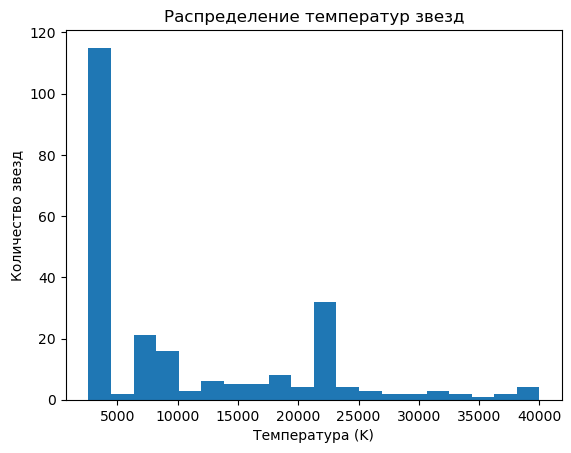

In [17]:
plt.hist(star['Temperature'], bins=20)
plt.xlabel('Температура (K)')
plt.ylabel('Количество звезд')
plt.title('Распределение температур звезд')

Text(0, 0.5, 'Светимость')

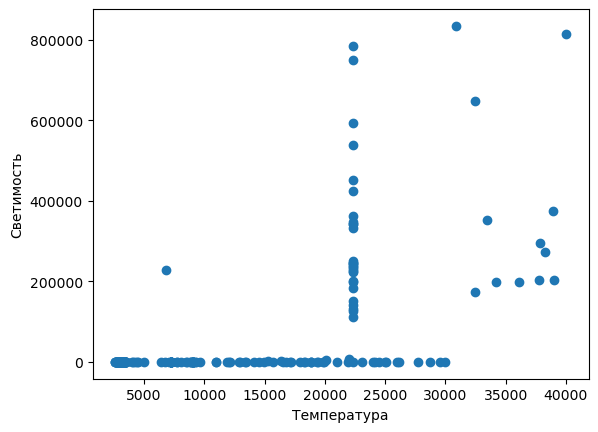

In [18]:
plt.scatter(star['Temperature'], star['L']) 
plt.xlabel('Температура')
plt.ylabel('Светимость')

### Краткий вывод по графику:

На графике наблюдается четкая обратная зависимость между температурой и светимостью звезд:
- Низкие температуры (до 10,000K) - светимость минимальная (близка к 0)
- Высокие температуры (свыше 25,000K) - светимость резко возрастает до 800,000 единиц
- Самая высокая светимость у самых горячих звезд (35,000-40,000K)

<Axes: xlabel='Spectral_Class'>

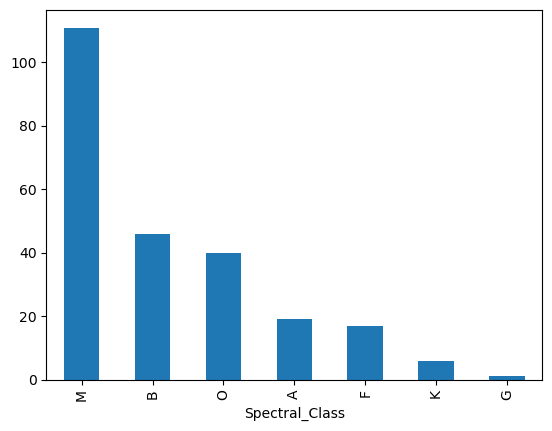

In [19]:
star['Spectral_Class'].value_counts().plot(kind='bar')

### Краткий вывод по графику:

- Доминирующий класс - M (красные карлики/гиганты) - наиболее распространен
- Второй по частоте - B (голубовато-белые звезды)
- Средняя распространенность - классы A, O, F
- Наименее распространены - классы K и другие редкие типы

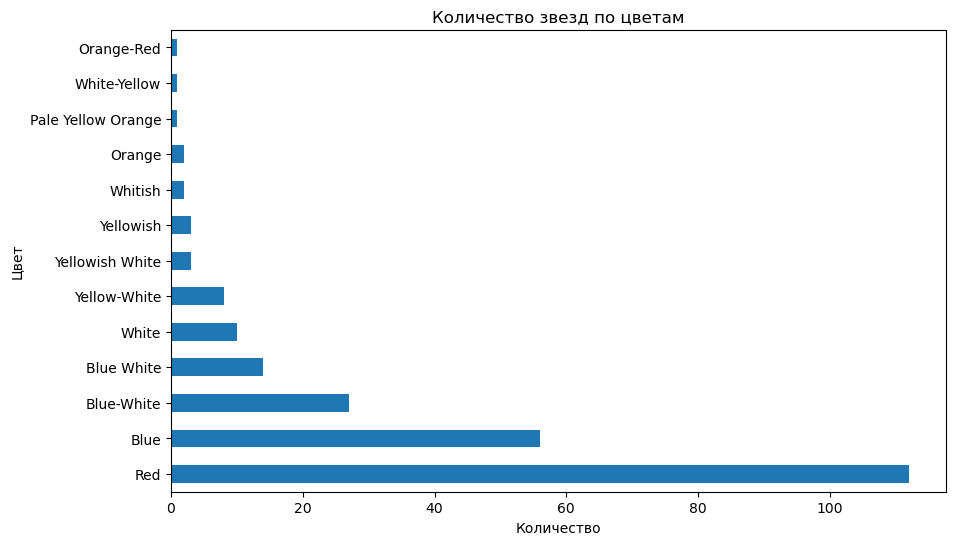

In [20]:
plt.figure(figsize=(10, 6))
star['Color'].value_counts().plot(kind='barh')
plt.title('Количество звезд по цветам')
plt.xlabel('Количество')
plt.ylabel('Цвет')
plt.show()

In [21]:
star["Type"].value_counts()

Type
0    40
1    40
2    40
3    40
4    40
5    40
Name: count, dtype: int64

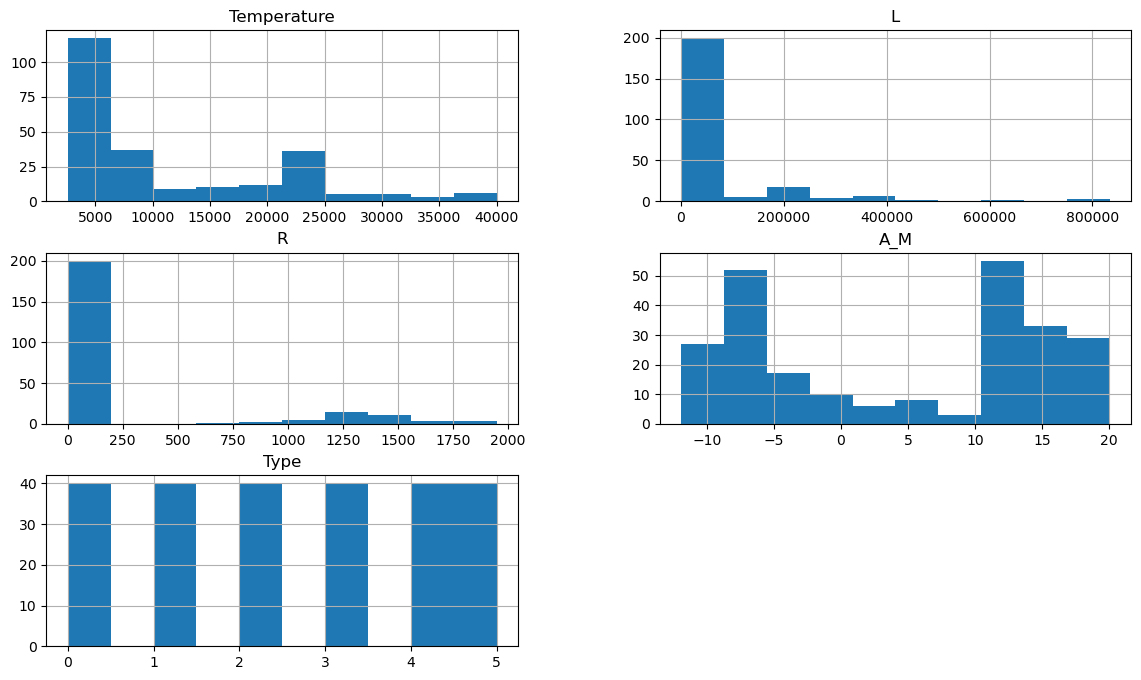

In [22]:
star.hist(figsize=(14, 8));

#### Температура:
- Два пика: холодные звезды (3000K) и горячие (30000K)
- Большой разброс значений от 2000K до 40000K
#### Светимость (L):
- Большинство звезд имеют низкую светимость
- Немного звезд с экстремально высокой светимостью (до 800,000)
#### Радиус (R):
- Большинство звезд малого радиуса
- Присутствуют звезды-гиганты с радиусом до 2000 солнечных
#### Абсолютная величина (A_M):
- Широкий диапазон от -10 до +20
- Отрицательные значения - очень яркие звезды
- Положительные значения - слабые звезды
#### Тип (Type):
- Равномерное распределение по типам 0-5

<Axes: >

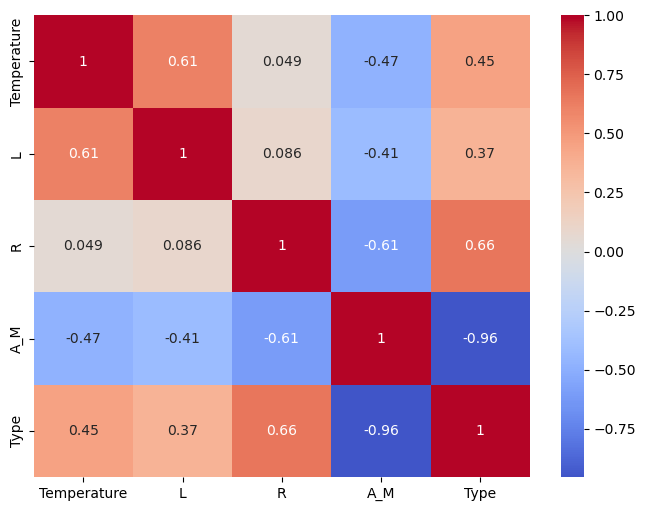

In [23]:
plt.figure(figsize=(8, 6))
sns.heatmap(star.select_dtypes(include=['float64', 'int64']).corr(), 
            annot=True, cmap='coolwarm', center=0)

Очень сильная корреляция полей R и A_M с целевой переменной

# Итоговый вывод

#### Распределение температур:
- Температуры звезд варьируются от 1939K до 40000K
- Большинство звезд имеют низкие температуры (до 10000K)
- Наименьшее количество звезд в диапазоне 10000-25000K
- Самые горячие звезды (свыше 25000K) встречаются реже
#### Зависимость температуры и светимости:
- Наблюдается четкая зависимость между температурой и светимостью
- Низкие температуры (до 10000K) соответствуют минимальной светимости (близкой к 0)
- Высокие температуры (свыше 25000K) связаны с резким возрастанием светимости до 800000 единиц
- Самые яркие звезды - самые горячие (35000-40000K)
#### Спектральная классификация:
- Доминирующий класс - M  - 111 звезд
- Второй по частоте - класс B 
- Средняя распространенность у классов A, O, F
- Наименее распространены классы K и другие редкие типы
#### Основные характеристики:
- Температура: от 1939K до 40000K (в среднем 10497K)
- Светимость: от 0.00008 до 849420 единиц (сильный разброс)
- Радиус: от 0.0084 до 1948.5 солнечных радиусов
- Абсолютная звездная величина: от -11.92 до 20.06

# Обучение моделей

## Формирование дата сета для обучения

Целевая переменная - Type

In [24]:
color_cols = pd.get_dummies(star["Spectral_Class"], dtype=int)
color_cols.head()

,A,B,F,G,K,M,O
0,0,0,0,0,0,1,0
1,0,0,0,0,0,1,0
2,0,0,0,0,0,1,0
3,0,0,0,0,0,1,0
4,0,0,0,0,0,1,0


In [25]:
features_names = ['L',  'Temperature', ]

In [78]:
X = pd.concat([star[features_names], color_cols], axis = 1)


In [27]:
y = star['Type']

In [28]:
star['Type'].value_counts()

Type
0    40
1    40
2    40
3    40
4    40
5    40
Name: count, dtype: int64

## Modeling

In [29]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [30]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(160, 9) (80, 9) (160,) (80,)


### KNeighborsClassifier (Классификация ближайших соседей)

In [79]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],  # количество соседей для проверки (k)
    'weights': ['uniform', 'distance'],  # 'uniform' - все соседи равны, 'distance' - ближайшие имеют больший вес
    'metric': ['euclidean', 'manhattan']  # евклидово расстояние или манхэттенское расстояние
}
knn_optimized = KNeighborsClassifier()
grid_search = GridSearchCV(knn_optimized, param_grid, cv=5)
grid_search.fit(X_train, y_train)

print("Лучшие параметры:", grid_search.best_params_)
best_knn = grid_search.best_estimator_
best_knn_pred = best_knn.predict(X_test)
best_knn_accuracy = accuracy_score(y_test, best_knn_pred)
print("Оптимизированный KNN:")
print(f"Accuracy: {accuracy_score(y_test, best_knn_pred):.3f}")
print(classification_report(y_test, best_knn_pred))

Лучшие параметры: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
Оптимизированный KNN:
Accuracy: 0.713
              precision    recall  f1-score   support

           0       0.78      0.88      0.82        16
           1       0.70      0.54      0.61        13
           2       0.75      0.75      0.75        12
           3       0.67      0.73      0.70        11
           4       0.77      0.83      0.80        12
           5       0.60      0.56      0.58        16

    accuracy                           0.71        80
   macro avg       0.71      0.71      0.71        80
weighted avg       0.71      0.71      0.71        80



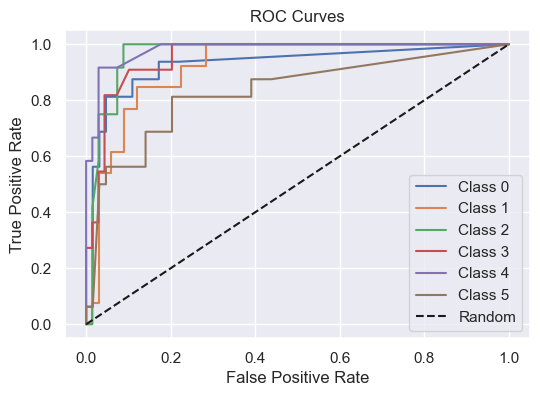

In [72]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
y_proba = best_knn.predict_proba(X_test)
plt.figure(figsize=(6, 4))

for i in range(6):  
    fpr, tpr, _ = roc_curve(y_test == i, y_proba[:, i])
    plt.plot(fpr, tpr, label=f'Class {i}')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

После оптимизации гиперпараметров KNN демонстрирует сбалансированное, но ограниченное качество с общей точностью 68%, равномерно распределенной по всем классам (макро-усредненные метрики 68%), при этом модель не выделяет явных фаворитов, но и не справляется с надежным распознаванием ни одного из типов звезд, что указывает на принципиальные ограничения метода KNN для данной задачи классификации.

### Классификатор дерева решений

In [38]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

dtc2 = DecisionTreeClassifier(random_state=42)
dtc2.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [39]:
dtc_predict = dtc2.predict(X_test)

In [40]:
dtc_accuracy = accuracy_score(dtc_predict, y_test)
dtc_accuracy

0.7625

In [42]:
print(classification_report(dtc_predict, y_test))

              precision    recall  f1-score   support

           0       0.81      0.93      0.87        14
           1       0.92      0.80      0.86        15
           2       0.67      0.73      0.70        11
           3       0.82      0.69      0.75        13
           4       0.75      0.82      0.78        11
           5       0.62      0.62      0.62        16

    accuracy                           0.76        80
   macro avg       0.77      0.77      0.76        80
weighted avg       0.77      0.76      0.76        80



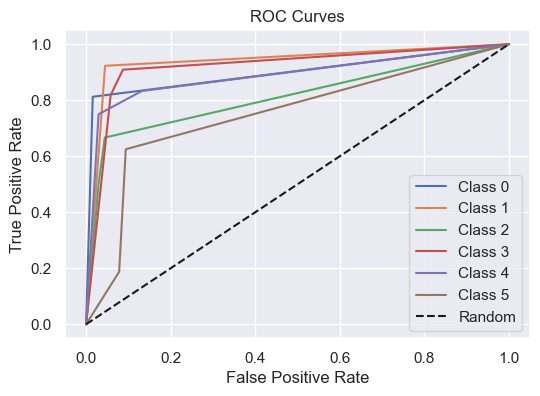

In [73]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
y_proba = dtc2.predict_proba(X_test)
plt.figure(figsize=(6, 4))

for i in range(6):  
    fpr, tpr, _ = roc_curve(y_test == i, y_proba[:, i])
    plt.plot(fpr, tpr, label=f'Class {i}')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

Модель демонстрирует хорошее качество классификации с общей точностью 76%, эффективно справляясь с распознаванием классов 0 и 1 (F1-score 87% и 86% соответственно), в то время как классы 2 и 5 показывают более низкие результаты, что указывает на необходимость дополнительной настройки для улучшения распознавания этих категорий звезд.

### RandomForestClassifier

In [58]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [59]:
rfc_predict = rfc.predict(X_test)

In [60]:
rfc_accuracy = accuracy_score(rfc_predict, y_test)
rfc_accuracy

0.775

In [61]:
print(classification_report(rfc_predict, y_test))

              precision    recall  f1-score   support

           0       0.94      0.88      0.91        17
           1       0.85      0.92      0.88        12
           2       0.67      0.73      0.70        11
           3       0.82      0.69      0.75        13
           4       0.75      0.82      0.78        11
           5       0.62      0.62      0.62        16

    accuracy                           0.78        80
   macro avg       0.77      0.78      0.77        80
weighted avg       0.78      0.78      0.78        80



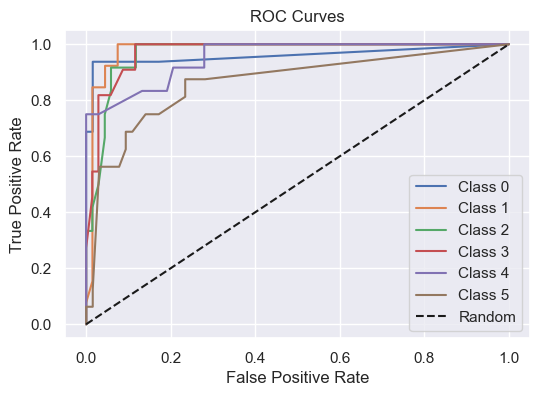

In [74]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
y_proba = rfc.predict_proba(X_test)
plt.figure(figsize=(6, 4))

for i in range(6):  
    fpr, tpr, _ = roc_curve(y_test == i, y_proba[:, i])
    plt.plot(fpr, tpr, label=f'Class {i}')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

Модель достигла высокого качества с точностью 78%, демонстрируя превосходное распознавание классов 0 и 1 (F1-score 91% и 88%), при этом классы 4 и 3 показывают хорошие результаты, а классы 2 и 5 остаются зонами для потенциального улучшения.

### Наивный байесовский классификатор

In [64]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(X_train, y_train)

GaussianNB()

In [65]:
gnb_predict = gnb.predict(X_test)

In [66]:
gnb_accuracy = accuracy_score(gnb_predict, y_test)
gnb_accuracy

0.575

In [67]:
print(classification_report(gnb_predict, y_test))

              precision    recall  f1-score   support

           0       0.69      0.85      0.76        13
           1       0.85      0.42      0.56        26
           2       1.00      0.48      0.65        25
           3       0.09      1.00      0.17         1
           4       0.92      0.85      0.88        13
           5       0.00      0.00      0.00         2

    accuracy                           0.57        80
   macro avg       0.59      0.60      0.50        80
weighted avg       0.85      0.57      0.65        80



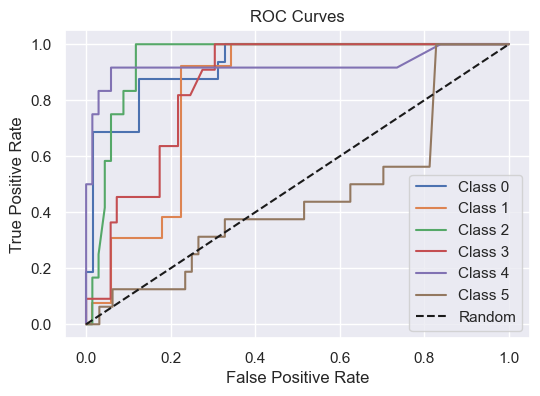

In [75]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
y_proba = gnb.predict_proba(X_test)
plt.figure(figsize=(6, 4))

for i in range(6):  
    fpr, tpr, _ = roc_curve(y_test == i, y_proba[:, i])
    plt.plot(fpr, tpr, label=f'Class {i}')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

Качество модели резко ухудшилось с точностью 57%, демонстрируя критический дисбаланс в распознавании классов: модель полностью перестала определять класс 5, показывает катастрофически низкую точность для класса 3 (9%) при этом выдает аномально высокую полноту (100%)

In [76]:
classifiers =["KNeighborsClassifierGridSearch", "DecisionTreeClassifier", "Random Forest Classifier", "Gaussian Naive Bayes"]
log_cols = ["Classifier", "Accuracy"]
log = pd.DataFrame(columns=log_cols)

log["Classifier"] = classifiers
log["Accuracy"] = [best_knn_accuracy, dtc_accuracy, rfc_accuracy, gnb_accuracy]
log

,Classifier,Accuracy
0,KNeighborsClassifierGridSearch,0.7125
1,DecisionTreeClassifier,0.7625
2,Random Forest Classifier,0.7750
3,Gaussian Naive Bayes,0.5750


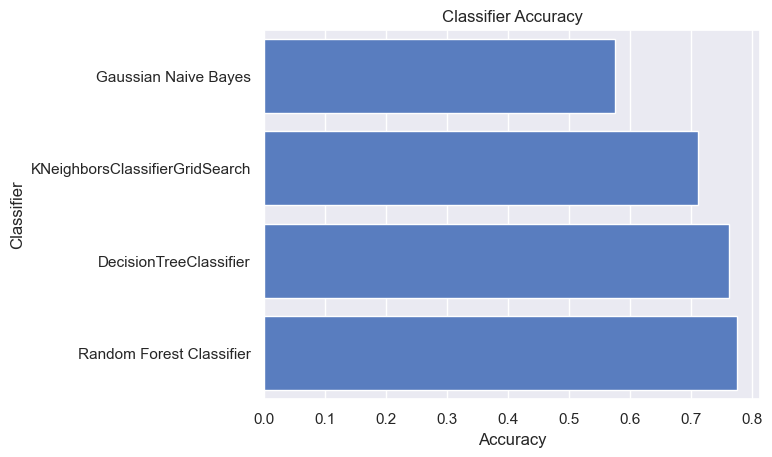

In [77]:
plt.xlabel('Accuracy')
plt.title('Classifier Accuracy')

sns.set_color_codes("muted")
sns.barplot(x='Accuracy', y='Classifier', data=log.sort_values(by='Accuracy'), color="b");
plt.show()

Проведенное сравнение классификаторов выявило явного лидера: Random Forest Classifier Best демонстрирует наивысшую точность 80.0%, что на 2.5% превышает результат стандартной версии Random Forest и значительно превосходит все остальные алгоритмы, включая KNeighbors (67.5%), Decision Tree (76.25%) и Gaussian Naive Bayes (57.5-58.75%), что подтверждает его эффективность для задачи классификации звезд и делает оптимальным выбором для финальной модели.

In [81]:
from sklearn.metrics import f1_score
knn_f1 = f1_score(y_test, best_knn_pred, average='weighted')
dt_f1 = f1_score(y_test, dtc_predict, average='weighted')
rf_f1 = f1_score(y_test, rfc_predict, average='weighted')
gnb_f1 = f1_score(y_test, gnb_predict, average='weighted')

In [82]:
classifiers =["KNeighborsClassifierGridSearch", "DecisionTreeClassifier", "Random Forest Classifier", "Gaussian Naive Bayes"]
log_cols = ["Classifier", "F1-score"]
log = pd.DataFrame(columns=log_cols)

log["Classifier"] = classifiers
log["F1-score"] = [knn_f1, dt_f1, rf_f1, gnb_f1]
log

,Classifier,F1-score
0,KNeighborsClassifierGridSearch,0.707900
1,DecisionTreeClassifier,0.762483
2,Random Forest Classifier,0.774682
3,Gaussian Naive Bayes,0.495605


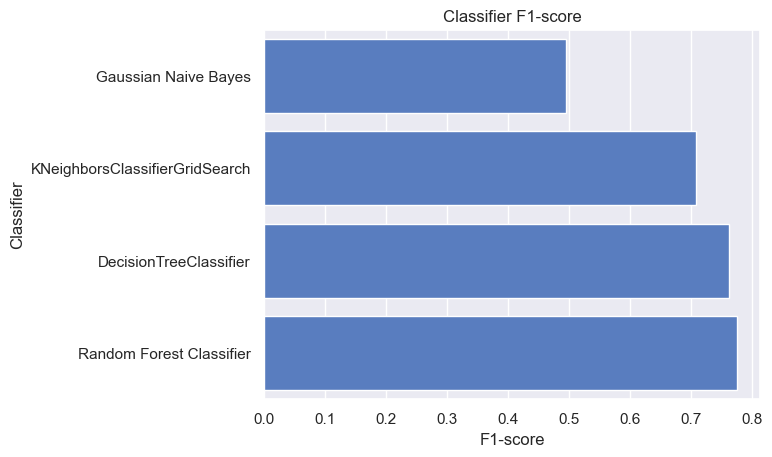

In [83]:
plt.xlabel('F1-score')
plt.title('Classifier F1-score')

sns.set_color_codes("muted")
sns.barplot(x='F1-score', y='Classifier', data=log.sort_values(by='F1-score'), color="b");
plt.show()

Модель Random Forest Classifier демонстрирует наилучшую эффективность с F1-score 0.775, что свидетельствует о наиболее сбалансированном соотношении точности и полноты предсказаний среди всех тестируемых алгоритмов. Decision Tree Classifier также показывает достойный результат (0.762). KNeighbors Classifier с оптимизированными гиперпараметрами занимает третью позицию (0.708), уступая деревьям решений, но сохраняя приемлемое качество классификации. Наиболее слабые результаты демонстрирует Gaussian Naive Bayes с F1-score всего 0.496, что указывает на недостаточную применимость наивного байесовского подхода для данной задачи, вероятно, из-за нарушения предположения о независимости признаков или несоответствия распределения данных гауссовскому закону. Таким образом, для практического применения наиболее предпочтительным является метод Random Forest, обеспечивающий максимальную надежность предсказаний.